In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()


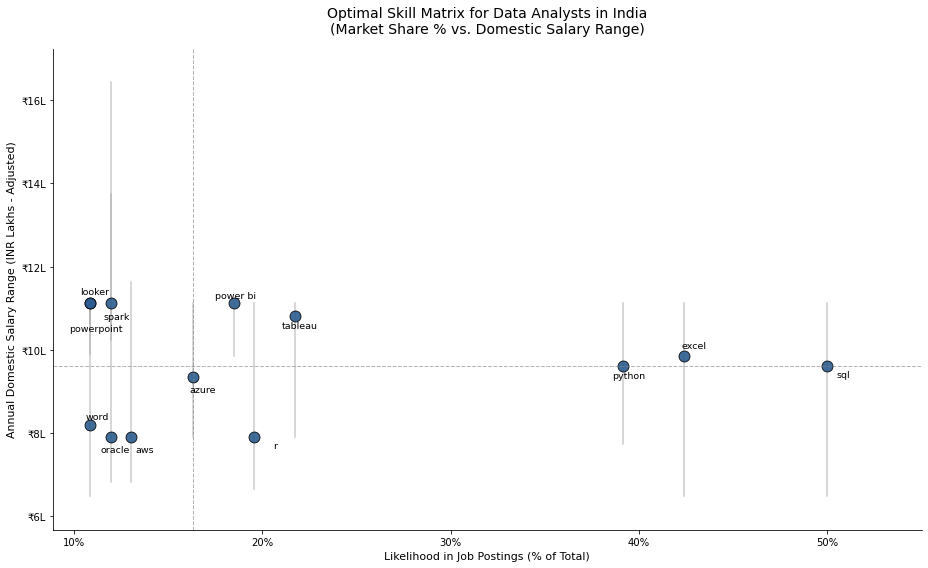

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import ast

Clean data:
df_india_clean = df.copy()

# Parse string from lists
df_india_clean['job_skills'] = df_india_clean['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
#Filter for data analysts in India
df_da_india = df_india_clean[
    (df_india_clean['job_country'] == 'India') & 
    (df_india_clean['job_title_short'] == 'Data Analyst')
].dropna(subset=['salary_year_avg']).copy()

# Log-Normal Outlier Trimming (Trims extreme MNC US-Remote Salaries)
df_da_india['log_salary'] = np.log(df_da_india['salary_year_avg'])

Q1_log = df_da_india['log_salary'].quantile(0.25)
Q3_log = df_da_india['log_salary'].quantile(0.75)
IQR_log = Q3_log - Q1_log
upper_bound_log = Q3_log + (1.0 * IQR_log)  # Trims heavy foreign remote upper outliers

df_da_trimmed = df_da_india[df_da_india['log_salary'] <= upper_bound_log].copy()
total_da_postings = len(df_da_trimmed)


# exploding dataset and finding ceiling and floor
df_da_exploded = df_da_trimmed.explode('job_skills')

df_optimal2 = df_da_exploded.groupby('job_skills')['salary_year_avg'].agg(
    median_salary='median',
    q25_salary=lambda x: np.percentile(x, 25),  # Realistic domestic floor
    q75_salary=lambda x: np.percentile(x, 75),  # Realistic domestic ceiling
    skill_count='count'
).reset_index()

# Market Share %
df_optimal2['skill_percentage'] = (df_optimal2['skill_count'] / total_da_postings) * 100
df_optimal2 = df_optimal2[df_optimal2['skill_percentage'] >= 10.0].copy()

#plotting matrix scatter plots:
fig, ax = plt.subplots(figsize=(13, 8)) 

        # 1. Draw Q25 to Q75 Range Bars for salary high and low points
for i in range(len(df_optimal2)):
    pct = df_optimal2['skill_percentage'].iloc[i]
    low = df_optimal2['q25_salary'].iloc[i]
    high = df_optimal2['q75_salary'].iloc[i]
    ax.plot([pct, pct], [low, high], color='#a8a8a8', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)

        # 2. Plot Median Scatters
sns.scatterplot(
    data=df_optimal2,
    x='skill_percentage',
    y='median_salary',
    s=120,
    color='#2b5c8f',
    alpha=0.9,
    edgecolor='black',
    ax=ax,
    zorder=2
)
#Labelling:
for i in range(len(df_optimal2)):
    pct = df_optimal2['skill_percentage'].iloc[i]
    sal = df_optimal2['median_salary'].iloc[i]
    skill_name = str(df_optimal2['job_skills'].iloc[i]).lower()
    
    x_offset = 0
    y_offset = 0
    ha_align = 'right'
    
   
    if skill_name == 'powerpoint':
        x_offset = 0.3  # Pushes PowerPoint left of the dot
        y_offset = -5000
        ha_align = 'center'
    elif skill_name == 'looker':
        x_offset = 1.0
        y_offset = 4000   # Shifts Looker above the dot
    elif skill_name == 'spark':
        x_offset = 1.0
        y_offset = -2000  # Shifts Spark below and slightly right
        
   
    elif skill_name == 'word':
        x_offset = 1.0
        y_offset = 3000   # Shifts Word above
    elif skill_name == 'oracle':
        x_offset = 1.0
        y_offset = -2000  # Shifts Oracle below
    elif skill_name == 'aws':
        x_offset = 1.2   # Shifts AWS further right
        y_offset = -2000
        
    elif skill_name == 'azure':
        x_offset = 1.2
        y_offset = -2000
    elif skill_name == 'power bi':
        x_offset = 1.2
        y_offset = 3000
    elif skill_name == 'tableau':
        x_offset = 1.2
        y_offset = -1200
    elif skill_name == 'r':
        x_offset = 1.2
        y_offset = -1200
    elif skill_name == 'python':
        x_offset = 1.2
        y_offset = -1200
    elif skill_name == 'excel':
        x_offset = 1.2
        y_offset = 3500
    elif skill_name == 'sql':
        x_offset = 1.2
        y_offset = -1000

    ax.text(
        x=pct + x_offset,
        y=sal + y_offset,
        s=skill_name,
        fontdict=dict(color='black', size=9.5),
        va='top',
        ha=ha_align
    )

# 4. Salary median
median_percentage = df_optimal2['skill_percentage'].median()
median_pay = df_optimal2['median_salary'].median()

ax.axvline(x=median_percentage, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=median_pay, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# 5. Xaxis percentage:
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# normalization and salary range conversion
DOMESTIC_INR_FACTOR = 10.5 / 100000
ticks_y = mtick.FuncFormatter(lambda x, pos: f"₹{int(x * DOMESTIC_INR_FACTOR)}L")
ax.yaxis.set_major_formatter(ticks_y)

# 6. Titles & Layout Limits
ax.set_title("Optimal Skill Matrix for Data Analysts in India\n(Market Share % vs. Domestic Salary Range)", fontsize=14, pad=15)
ax.set_xlabel("Likelihood in Job Postings (% of Total)", fontsize=11)
ax.set_ylabel("Annual Domestic Salary Range (INR Lakhs - Adjusted)", fontsize=11)

ax.set_xlim(df_optimal2['skill_percentage'].min() - 2, df_optimal2['skill_percentage'].max() + 5)
ax.set_ylim(df_optimal2['q25_salary'].min() - 8000, df_optimal2['q75_salary'].max() + 8000)

sns.despine()
plt.tight_layout()
plt.savefig('my_plot_ds.png', facecolor='white', transparent=False, bbox_inches='tight', dpi=300)
plt.show()